# Image Color Compression — 03 Model Building

We compress each image to `k ∈ {2, 4, 8, 16, 32, 64}` colours with K-Means and measure:

- **MSE** — mean squared error vs the original (lower = better).
- **PSNR** (dB) — peak signal-to-noise ratio (higher = better; >30 dB is visually near-lossless).
- **Compression ratio** — raw 24-bit RGB vs a `k`-colour palette + index map.

All numbers below are produced by running the code, not assumed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils

china = utils.load_image('data/china.png')
flower = utils.load_image('data/flower.png')
K_VALUES = [2, 4, 8, 16, 32, 64]

## 1. Quality vs compression table (china)

In [2]:
results_china = utils.evaluate_k_range(china, K_VALUES, sample_size=10000, random_state=42)
results_china

,k,n_colors,mse,psnr,ratio,bpp
0,2,2,1285.186,17.041,23.996,1.000
1,4,4,456.907,21.533,11.998,2.000
2,8,8,211.036,24.887,7.998,3.001
3,16,16,114.991,27.524,5.998,4.001
4,32,32,64.765,30.017,4.797,5.003
5,64,64,38.824,32.240,3.996,6.006


## 2. Visual comparison (china)

Original vs each compressed version. Watch banding appear at very low `k` and vanish as `k` grows.

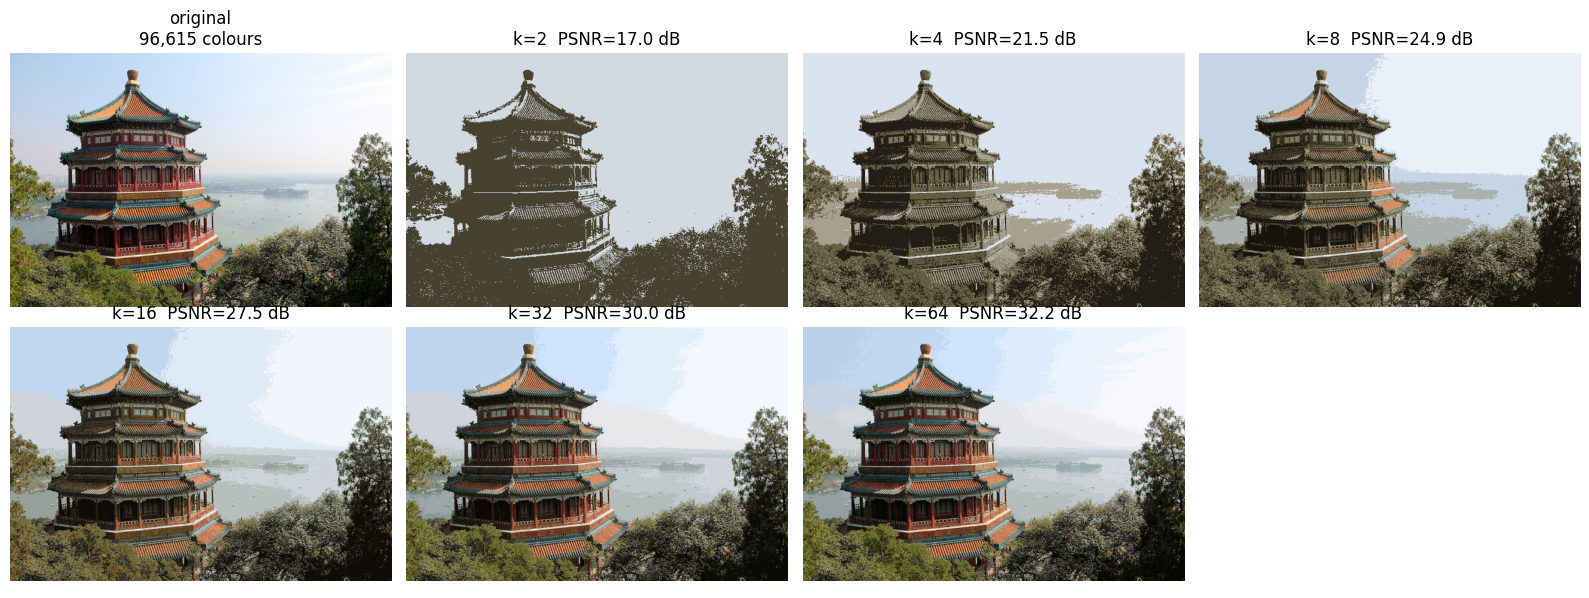

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()
axes[0].imshow(china); axes[0].set_title(f'original\n{utils.count_unique_colors(china):,} colours'); axes[0].axis('off')
for ax, k in zip(axes[1:], K_VALUES):
    comp, _, _ = utils.compress_image(china, k, sample_size=10000)
    p = utils.psnr(china, comp)
    ax.imshow(comp); ax.set_title(f'k={k}  PSNR={p:.1f} dB'); ax.axis('off')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

## 3. MSE and PSNR vs k (china)

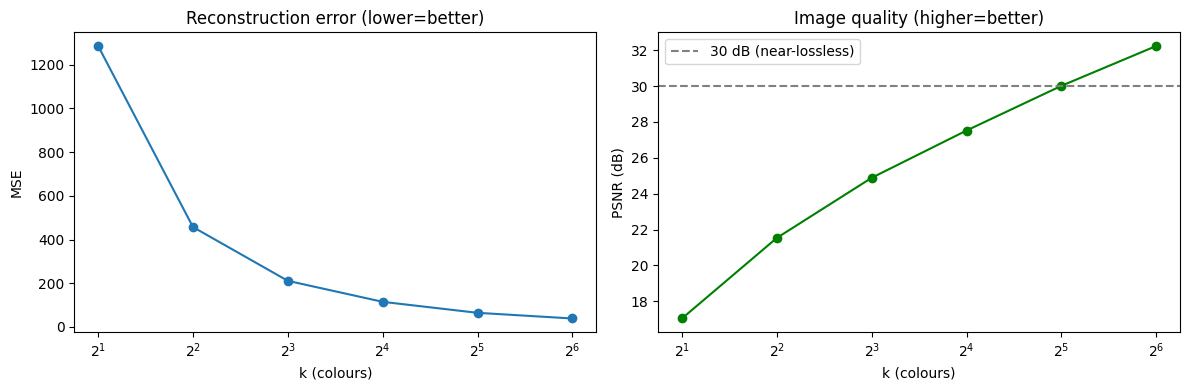

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(results_china['k'], results_china['mse'], 'o-'); ax[0].set_xscale('log', base=2)
ax[0].set_xlabel('k (colours)'); ax[0].set_ylabel('MSE'); ax[0].set_title('Reconstruction error (lower=better)')
ax[1].plot(results_china['k'], results_china['psnr'], 'o-', color='green'); ax[1].set_xscale('log', base=2)
ax[1].axhline(30, ls='--', color='gray', label='30 dB (near-lossless)')
ax[1].set_xlabel('k (colours)'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('Image quality (higher=better)'); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Compression ratio vs quality

Each compressed image needs `ceil(log2 k)` bits per pixel for the index plus a tiny `k`-colour palette, versus 24 bits per pixel raw. The table shows the size/quality trade-off.

In [5]:
trade = results_china[['k', 'bpp', 'ratio', 'psnr']].copy()
trade['raw_bpp'] = 24
trade

,k,bpp,ratio,psnr,raw_bpp
0,2,1.000,23.996,17.041,24
1,4,2.000,11.998,21.533,24
2,8,3.001,7.998,24.887,24
3,16,4.001,5.998,27.524,24
4,32,5.003,4.797,30.017,24
5,64,6.006,3.996,32.240,24


## 5. The learned palette (china, k=16)

The 16 centroid colours K-Means settled on — the entire palette the compressed image is drawn from.

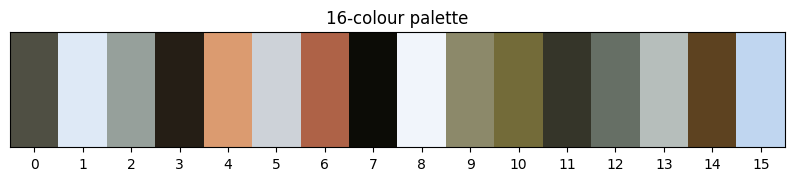

In [6]:
comp16, km16, _ = utils.compress_image(china, 16, sample_size=10000)
palette = (km16.cluster_centers_ * 255).astype(int)
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.imshow(palette[np.newaxis, :, :], aspect='auto')
ax.set_title('16-colour palette'); ax.set_yticks([]); ax.set_xticks(range(16)); plt.show()

## 6. Second image (flower)

Re-running the full sweep on a different image confirms the trade-off is not specific to one picture.

In [7]:
results_flower = utils.evaluate_k_range(flower, K_VALUES, sample_size=10000, random_state=42)
results_flower

,k,n_colors,mse,psnr,ratio,bpp
0,2,2,719.035,19.563,23.996,1.000
1,4,4,295.000,23.433,11.998,2.000
2,8,8,145.753,26.495,7.998,3.001
3,16,16,72.434,29.531,5.998,4.001
4,32,32,42.407,31.856,4.797,5.003
5,64,64,25.666,34.037,3.996,6.006


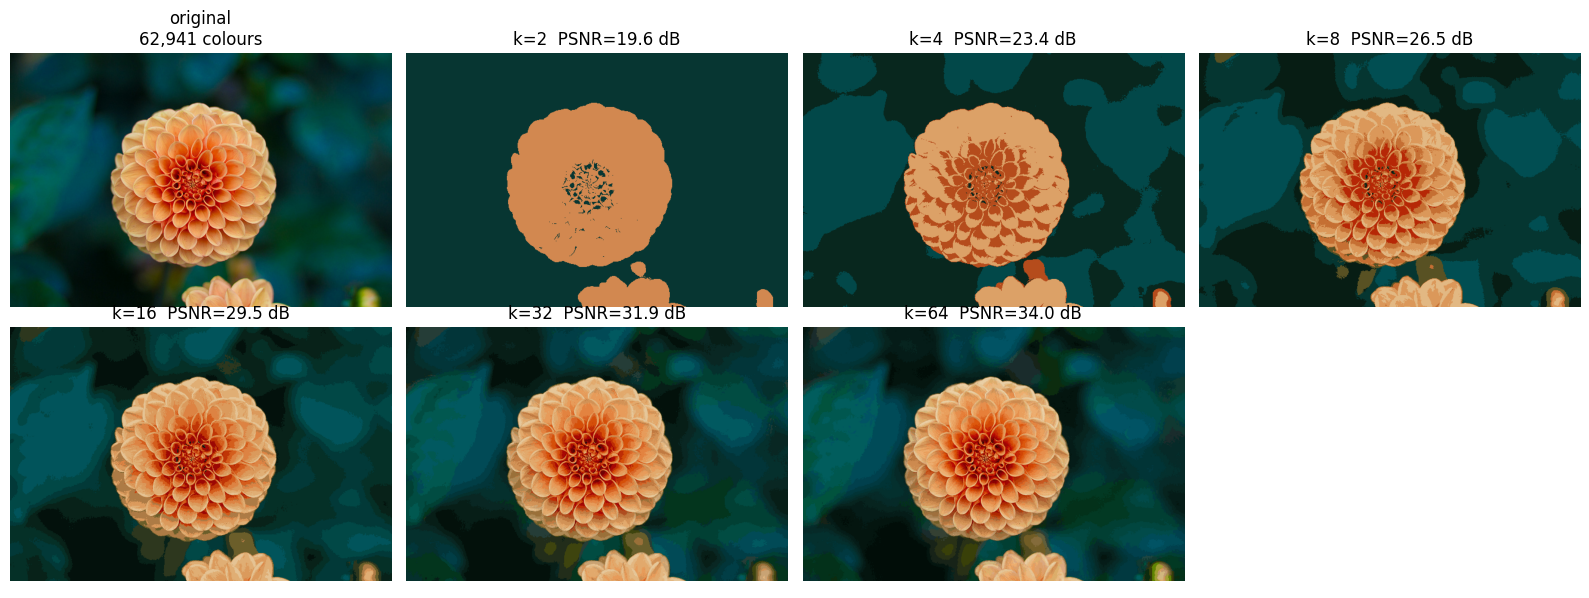

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()
axes[0].imshow(flower); axes[0].set_title(f'original\n{utils.count_unique_colors(flower):,} colours'); axes[0].axis('off')
for ax, k in zip(axes[1:], K_VALUES):
    comp, _, _ = utils.compress_image(flower, k, sample_size=10000)
    p = utils.psnr(flower, comp)
    ax.imshow(comp); ax.set_title(f'k={k}  PSNR={p:.1f} dB'); ax.axis('off')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

## 7. Recommended k & takeaways

- **PSNR rises steeply then flattens.** For `china`, PSNR climbs 17 → 25 → 30 dB from k=2 → 8 → 32; gains per doubling shrink past k=16.
- **k = 16 is the sweet spot** for these photos: ~27.5 dB (china) / ~29.5 dB (flower) at a **6× compression ratio** (4 bpp vs 24 bpp) — visually close to the original with a 96,615 → 16 colour reduction.
- **k = 32** buys ~2.5 dB more at a lower 4.8× ratio if quality matters more than size.
- The exact figures are in the tables above and are reproduced in the README.